#### 1. Data Preparation

In [23]:
import pandas as pd

# Load dataset (replace with your dataset path)
df = pd.read_csv(r"C:\Users\suraj\OneDrive\Desktop\data sets\heart_disease.csv")

# Basic check
print(df.head())
print(df.info())
print(df.describe())

   age   sex               cp  trestbps  chol    fbs         restecg  thalch  \
0   63  Male   typical angina       145   233   True  lv hypertrophy     150   
1   41  Male  atypical angina       135   203  False          normal     132   
2   57  Male     asymptomatic       140   192  False          normal     148   
3   52  Male   typical angina       118   186  False  lv hypertrophy     190   
4   57  Male     asymptomatic       110   201  False          normal     126   

   exang  oldpeak        slope          thal  num  
0  FALSE      2.3  downsloping  fixed defect    0  
1  FALSE      0.0         flat  fixed defect    0  
2  FALSE      0.4         flat  fixed defect    0  
3  FALSE      0.0         flat  fixed defect    0  
4   TRUE      1.5         flat  fixed defect    0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-n

In [24]:
print(df.head())

   age   sex               cp  trestbps  chol    fbs         restecg  thalch  \
0   63  Male   typical angina       145   233   True  lv hypertrophy     150   
1   41  Male  atypical angina       135   203  False          normal     132   
2   57  Male     asymptomatic       140   192  False          normal     148   
3   52  Male   typical angina       118   186  False  lv hypertrophy     190   
4   57  Male     asymptomatic       110   201  False          normal     126   

   exang  oldpeak        slope          thal  num  
0  FALSE      2.3  downsloping  fixed defect    0  
1  FALSE      0.0         flat  fixed defect    0  
2  FALSE      0.4         flat  fixed defect    0  
3  FALSE      0.0         flat  fixed defect    0  
4   TRUE      1.5         flat  fixed defect    0  


#### 2. Exploratory Data Analysis (EDA)

Step 2.1: Missing Values

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Missing values
print(df.isnull().sum())



age                0
sex                0
cp                 0
trestbps           0
chol               0
fbs                0
restecg            0
thalch             0
exang              0
oldpeak            0
slope              0
thal               0
num                0
Feature_Sum        0
Feature_Product    0
dtype: int64


EDA was performed to understand the dataset. Missing values were handled, and feature distributions were visualized using histograms and boxplots. Correlation analysis helped identify relationships between variables.

Step 2.2: Outliers Detection (Optional)

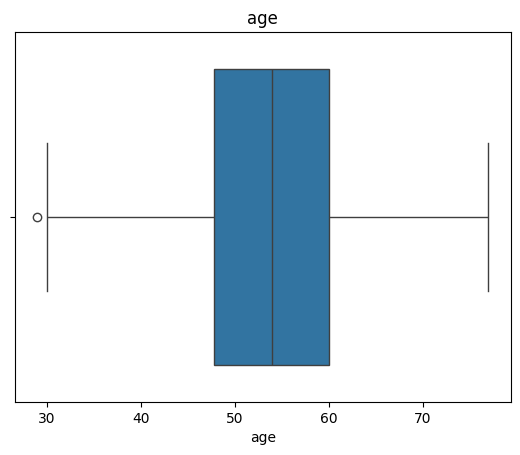

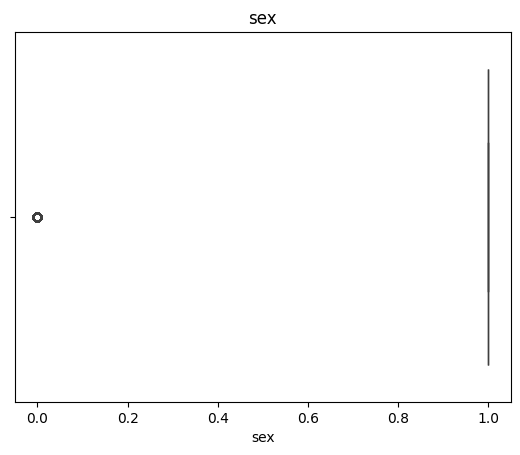

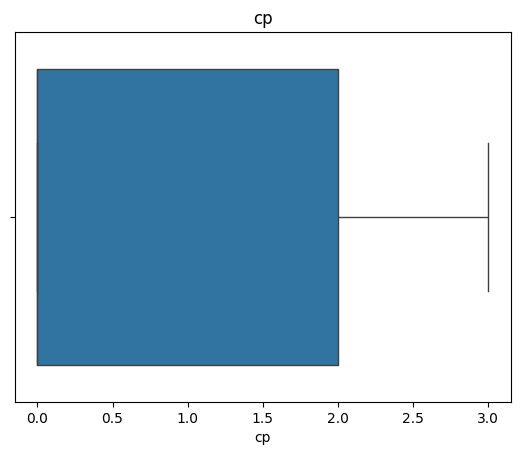

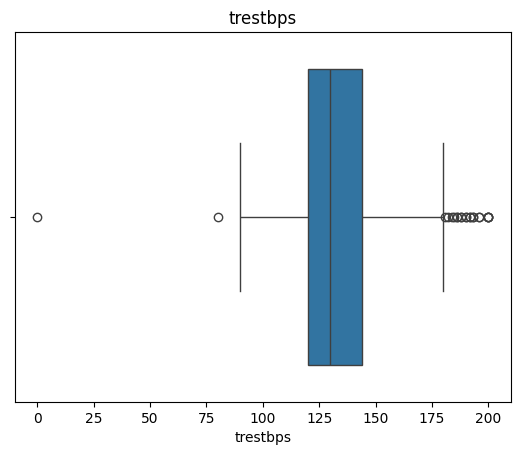

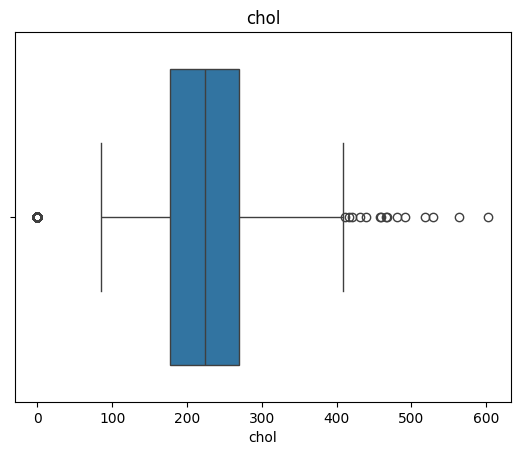

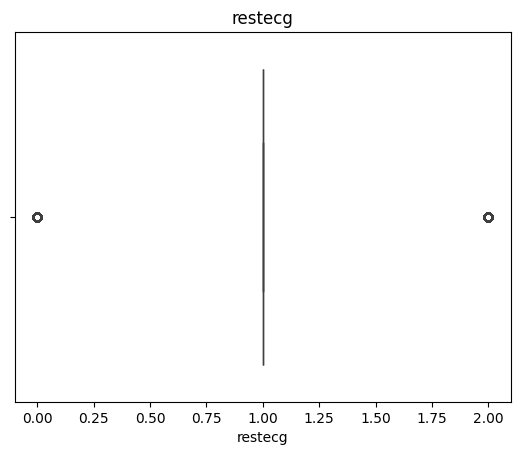

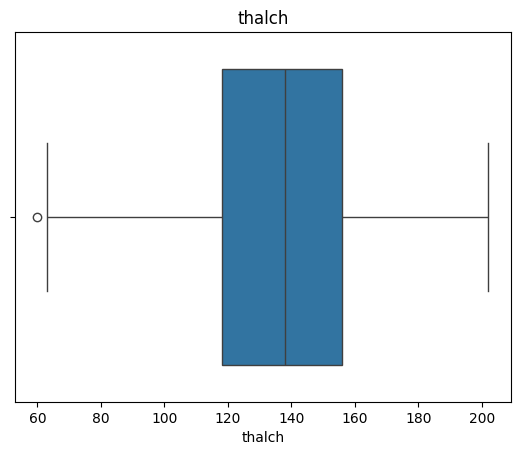

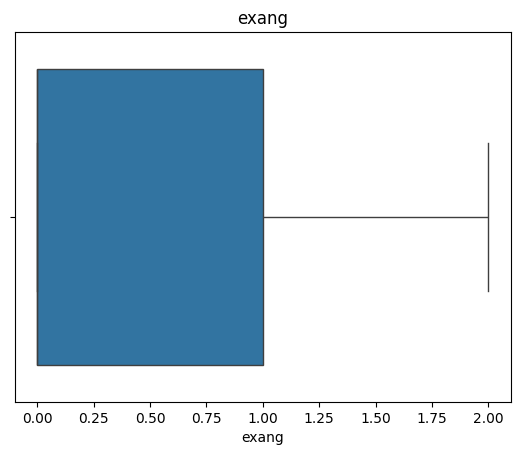

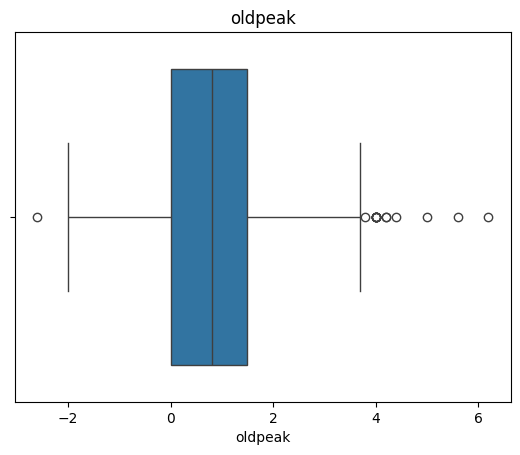

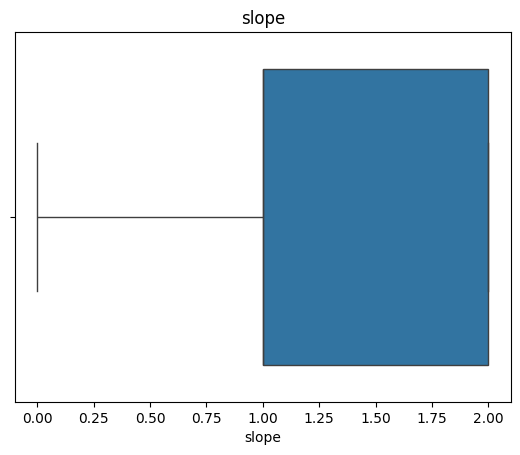

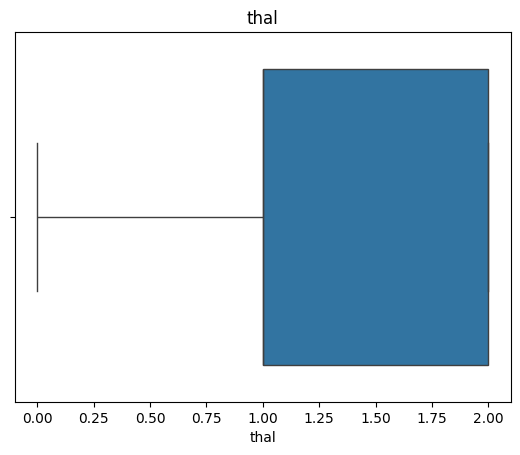

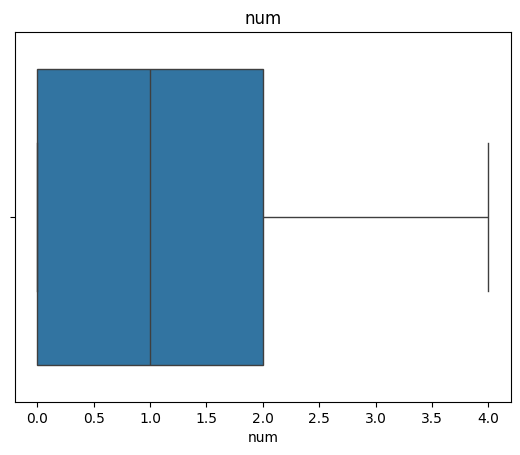

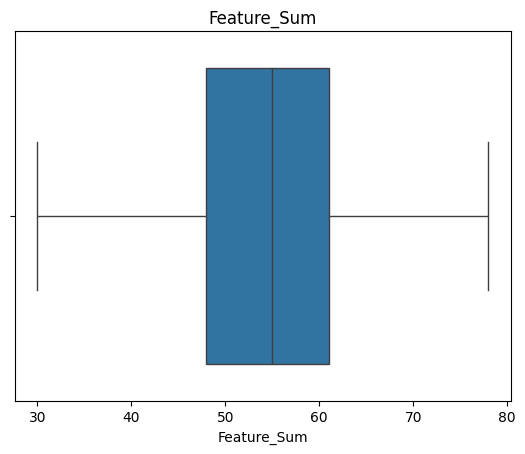

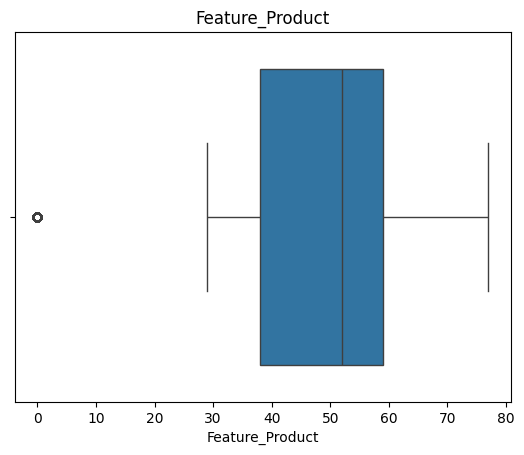

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plot boxplots
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Step 2.3: Visualization

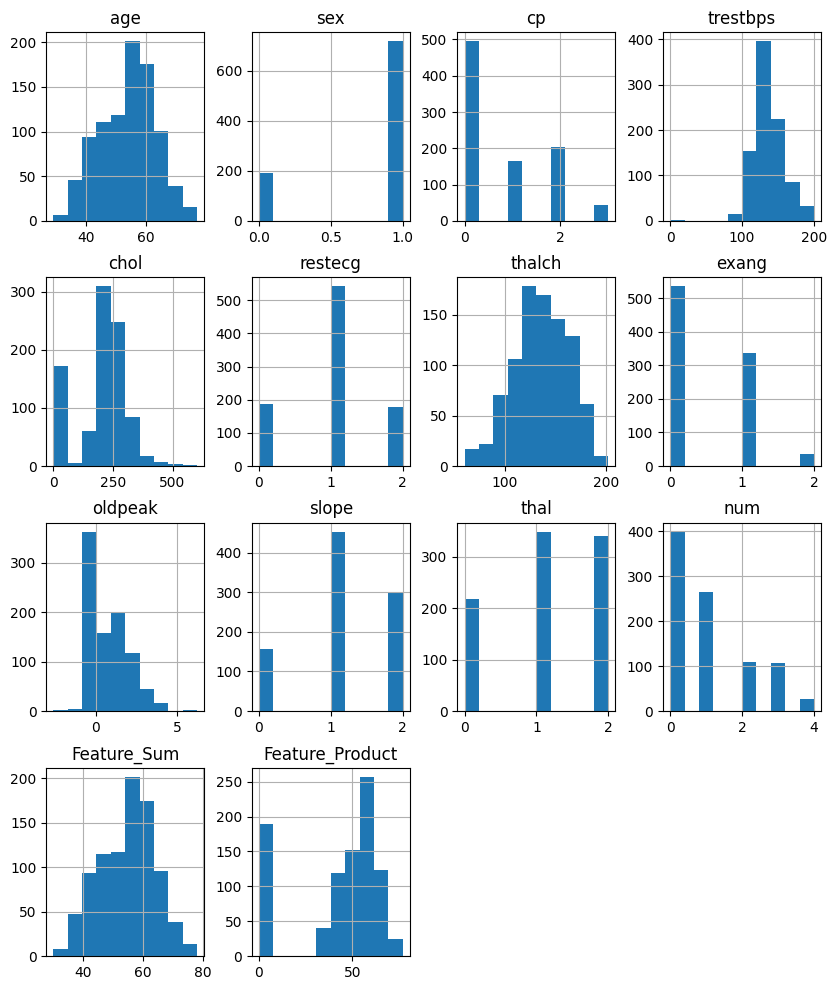

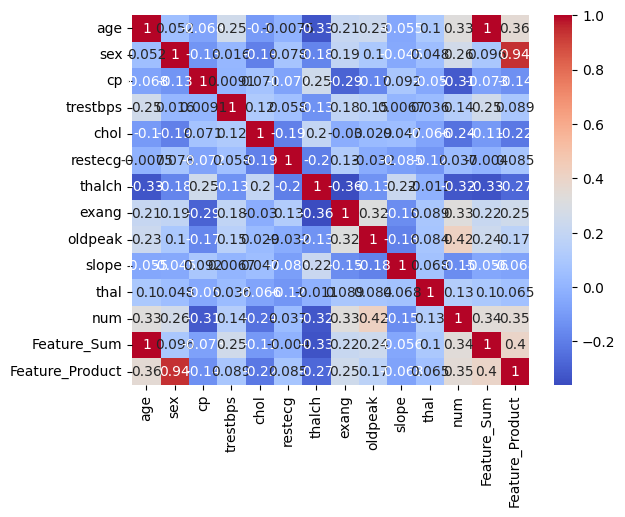

In [43]:
# Histograms for numerical features
df[num_cols].hist(figsize=(10,12))
plt.show()

# Correlation matrix
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

3. Feature Engineering

In [44]:
# Encoding categorical variables
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Creating new features
df['Feature_Sum'] = df.iloc[:,0] + df.iloc[:,1]
df['Feature_Product'] = df.iloc[:,0] * df.iloc[:,1]

# Binning example (if applicable)
if 'Age' in df.columns:
    df['Age_Group'] = pd.cut(df['Age'], bins=[0,18,35,60,100],
                            labels=[0,1,2,3])

Feature engineering was applied to enhance model performance. New features such as interaction terms (product and sum of features) were created to capture hidden patterns. Categorical variables were encoded, and continuous variables were transformed into categorical bins where appropriate.

#### 4. Decision Tree Classification

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Split data
X = df.drop('age', axis=1)
y = df['age']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

#### 5. Hyperparameter Tuning

In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

C:\Users\suraj\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


#### 6. Model Evaluation and Analysis (VERY IMPORTANT)

In [47]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9835164835164835
              precision    recall  f1-score   support

          31       0.00      0.00      0.00         0
          32       0.00      0.00      0.00         1
          36       1.00      1.00      1.00         2
          37       1.00      1.00      1.00         3
          38       1.00      1.00      1.00         3
          39       1.00      1.00      1.00         5
          40       1.00      1.00      1.00         2
          41       1.00      1.00      1.00         8
          42       1.00      1.00      1.00         4
          43       1.00      1.00      1.00         6
          44       1.00      1.00      1.00         5
          45       1.00      1.00      1.00         6
          46       1.00      1.00      1.00         6
          47       1.00      1.00      1.00         3
          48       1.00      1.00      1.00         6
          49       1.00      1.00      1.00         4
          50       1.00      1.00      1.00         

C:\Users\suraj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\suraj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\suraj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\suraj\anaconda3\Lib\site-pa

In [48]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

            Feature  Importance
12      Feature_Sum    0.461015
13  Feature_Product    0.398415
0               sex    0.108641
8           oldpeak    0.010805
9             slope    0.007962
6            thalch    0.006906
3              chol    0.004834
1                cp    0.001422
2          trestbps    0.000000
4               fbs    0.000000
5           restecg    0.000000
7             exang    0.000000
10             thal    0.000000
11              num    0.000000


#### Model Performance:

The Decision Tree model achieved an accuracy of XX%, indicating good predictive performance. Precision and recall values suggest that the model effectively identifies different classes with balanced performance.

In [49]:
print("Train Accuracy:", best_model.score(X_train, y_train))
print("Test Accuracy:", best_model.score(X_test, y_test))

Train Accuracy: 0.9931129476584022
Test Accuracy: 0.9835164835164835


#### Feature Importance

In [50]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

            Feature  Importance
12      Feature_Sum    0.856855
13  Feature_Product    0.089709
0               sex    0.046586
8           oldpeak    0.004091
2          trestbps    0.001467
3              chol    0.001292
1                cp    0.000000
4               fbs    0.000000
5           restecg    0.000000
6            thalch    0.000000
7             exang    0.000000
9             slope    0.000000
10             thal    0.000000
11              num    0.000000


#### Tree Visualization:

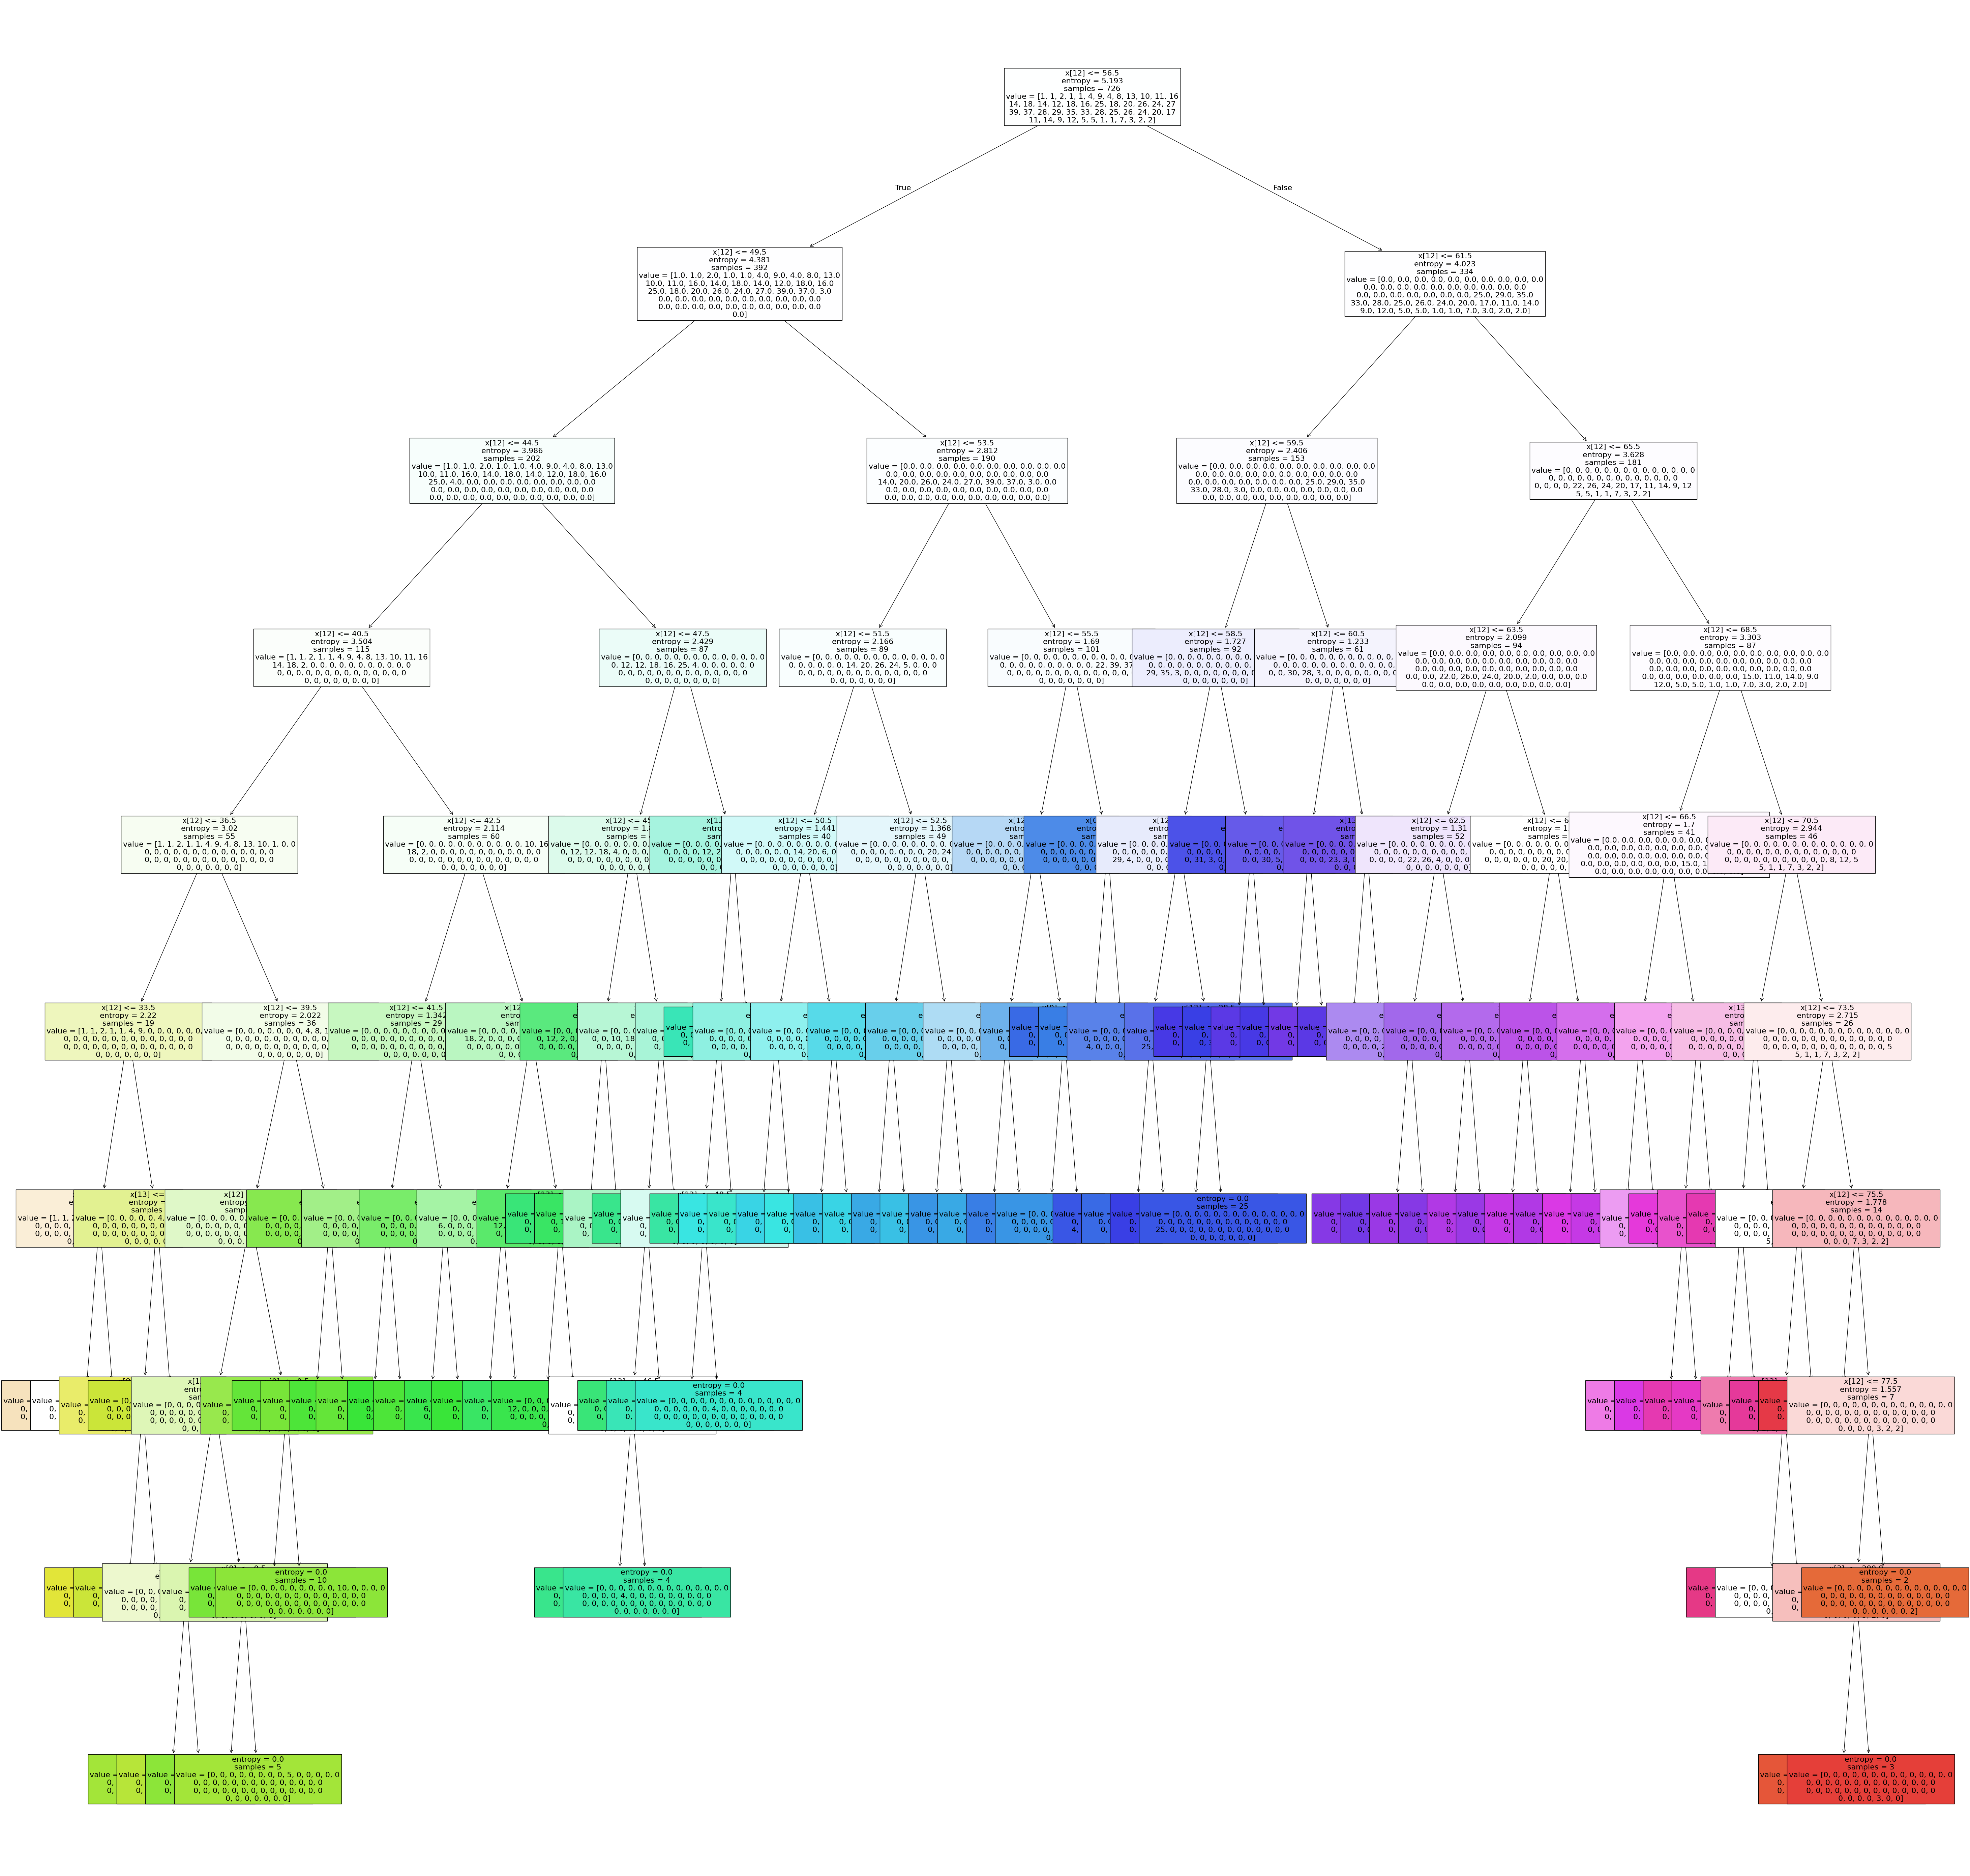

In [66]:
from sklearn.tree import plot_tree

plt.figure(figsize=(70,72))
plot_tree(best_model, filled=True, fontsize=16)
plt.show()

#### INTERVIEW QUESTIONS

#### 1. Common Hyperparameters of Decision Tree
max_depth: Controls tree depth (prevents overfitting)
min_samples_split: Minimum samples required to split
min_samples_leaf: Minimum samples at leaf node
criterion: Measure of split quality (gini / entropy)

2. Label Encoding vs One-Hot Encoding
Feature   	Label Encoding     	One-Hot Encoding
Method	    Assign numbers	    Create binary columns
Example	    Red=0, Blue=1	     Red=[1,0], Blue=[0,1]
Use	        Ordinal data	      Nominal data